<a href="https://colab.research.google.com/github/lmendezayl/uba-optimizacion-tp1/blob/main/tp1_optimizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes Neuronales: Aplicacion del Metodo de Descenso por Gradiente

Para esta primera parte trabajaremos con el archivo `utils_tools.jl`, el dataset `Iris` y seguiremos los lineamientos vistos aquı. Utilizaremos una red con tres capas (con funciones de activacion ReLu, identidad y softmax) de 5 niveles.

In [1]:
import Pkg; Pkg.add("RDatasets")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [2]:
using LinearAlgebra, RDatasets, Random, Statistics, Plots

In [3]:
iris = dataset("datasets", "iris")
X = Matrix(iris[:, 1:4])
y = iris.Species

150-element CategoricalArrays.CategoricalArray{String,1,UInt8}:
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 ⋮
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"

In [4]:
# utils_tools.jl
function split(X, y; dims=1, ratio_train=0.8)
    n = length(y)

    n_train = round(Int, ratio_train*n) # Redondeamos el corte
    i_rand = randperm(n)				# Permutamos los indices
    i_train = i_rand[1:n_train] 		# Usamos el 80% para train
    i_test = i_rand[n_train+1:end] 		# El resto lo usamos para test

    X_train = X[i_train,:]
    y_train = y[i_train]
    X_test  = X[i_test, :]
    y_test  = y[i_test]
    return X_train, y_train, X_test, y_test

end

function normalize(X_train, X_test; dims=1)
    col_mean = mean(X_train; dims)
    col_std = std(X_train; dims)

    return (X_train .- col_mean) ./ col_std, (X_test .- col_mean) ./ col_std
end

function onehot(y, classes)
	y_onehot = zeros(length(classes), length(y))
	num_of_class = 1:length(classes)

	for i in 1:length(y)
		y_onehot[:,i] = y[i].==classes
	end
	return y_onehot
end

function prepare_data(X, y; do_normal=true, do_onehot=true, kwargs...)
    X_train, y_train, X_test, y_test = split(X, y)

    if do_normal
        X_train, X_test = normalize(X_train, X_test; kwargs...)
    end

    classes = unique(y)

    if do_onehot
        y_train = onehot(y_train, classes)
        y_test = onehot(y_test, classes)
    end

    return X_train', y_train, X_test', y_test, classes
end

X_train, y_train, X_test, y_test, classes = prepare_data(X, y)

mean_tuple(d::AbstractArray{<:Tuple}) = Tuple([mean([d[k][i] for k in 1:length(d)]) for i in 1:length(d[1])])

grad_total(modelo,grad,x,y) = mean_tuple([grad(modelo, X_train[:,k], y_train[:,k]) for k in 1:size(X_train,2)])

# funciones de activacion
relu(x) = max.(0,x)
id(x) = x
softmax(x) = exp.(x) ./ sum(exp.(x), dims=1)

softmax (generic function with 1 method)

In [5]:
println(size(X_train, 1))
println(size(X_train, 2))
println(size(y_train, 1))
println(size(y_train, 2))

4
120
3
120


In [6]:
mutable struct RedNeuronal{T<:Real}
	# Utilizaremos una red neuronal con tres capas con funciones de activacion ReLU,
	# identidad y softmax de 5 niveles.
	#
	# Nota: no es como Python, no hace falta definir una clase, ni tapoco
	# hace falta definir atributos como __init__ para poder definir el llamado a
	# el constructor de esta clase. Aca directamente llamamos
	# m = RedNeuronal(W1, b1, W2, b2)
	# y listo, con esto es suficiente para crear el modelo.
	#
	# El downside es que no podemos crear metodos bajo el struct RedNeuronal
	W1::Matrix{T} # l1 -> l2
	b1::Vector{T}
	W2::Matrix{T} # l2 -> l3
	b2::Vector{T}
end

# creamos el modelo con el constructor de Red Neuronal
Random.seed!(73)
W1 = randn(5, size(X_train, 1)) # este 1 era un 2, tomando una matriz de 5x4 enlugar de 5x120!
b1 = randn(5)
W2 = randn(size(y_train, 1), 5)
b2 = randn(size(y_train, 1 ))

model = RedNeuronal(W1, b1, W2, b2)

RedNeuronal{Float64}([1.2123689466501288 -1.8659948470385643 1.5359646820970976 -2.946693261135319; 0.07867339151355215 -0.5409383051722126 1.904244155888974 0.4000651169550351; … ; -1.4081384368973173 0.3566138060639536 0.758845608555424 -0.2462781339520417; 0.4644730607385192 -0.4580210630616379 -2.3363570247525765 0.6032439841236702], [0.036509117320801934, 2.0183941863348958, -1.4222121770628655, -0.02458224672669713, 0.5662594627526059], [0.9865857065343743 0.5569751877519062 … -0.013964807677120253 -1.1131349472530667; 0.5499123327973198 0.12834599681305806 … -0.7764680654747667 0.36181588423766176; -0.7411473285232308 -0.06050648910140387 … -0.7658544536287244 2.1530628891736723], [-0.14226841165752968, -1.0368122047759714, -0.14131008223303249])

## Ejercicio 1
Implementar una función `forward_pass(model,x)` que para cada dato $x$ retorne la predicción según el modelo.

In [7]:
function forward_pass(model, X) # Done
	# Implementar una funcion que para cada dato x retorne la prediccion segun
	# el modelo.
	W1, b1, W2, b2 = model.W1, model.b1, model.W2, model.b2
	z_1 = W1 * X .+ b1
	size(z_1)
	a_1 = relu(z_1)
	z_2 = W2 * a_1 .+ b2
	a_2 = z_2
	y = softmax(a_2)
	return y
end

forward_pass (generic function with 1 method)

In [8]:
# Evaluamos la salida del modelo para el primer dato
forward_pass(model, X_train[:,1])

3-element Vector{Float64}:
 0.8918887448126508
 0.05285118262132958
 0.05526007256601966

In [9]:
# Evaluamos la salida del modelo para los 120 datos, viene en forma de matriz
forward_pass(model, X_train)

3×120 Matrix{Float64}:
 0.891889   0.949893   0.973409    …  0.985236     0.985543     0.906673
 0.0528512  0.0378251  0.0255587      0.0145926    0.0141894    0.0469991
 0.0552601  0.0122824  0.00103224     0.000171416  0.000268055  0.0463283

## Ejercicio 2
Implementar una función `grad(model,x,y)` que calcule el gradiente de la función de pérdida para cada par de datos $(x,y)$ utilizando $\texttt{back-propagation}$. Y utilizarla para calcular el gradiente completo usando la función `grad_total` de `utils_tools.jl`.

In [10]:
function grad(model, X, y)
    # Implementar una funcion que calcule el gradiente de la funcion de perdida para
    # cada par de datos (x,y) utilizando backprop. Usarla para calcular el grad completo
    # usando la funcion grad_total de utils_tools.jl

    # Obtenemos los datos del modelo
    W1, b1, W2, b2 = model.W1, model.b1, model.W2, model.b2

    # Hacemos el forward pass
    z_1 = W1 * X .+ b1
    a_1 = relu.(z_1)
    z_2 = W2 * a_1 .+ b2
    y_pred = softmax(z_2)

    # Definimos la derivada de la relu
    relu_prime(X) = X > 0 ? 1.0 : 0.0 # heaviside = relu'

    delta_2 = y_pred .- y # https://eli.thegreenplace.net/2016/the-softmax-function-and-its-derivative/
    grad_W2 = delta_2 * a_1'
    grad_b2 = delta_2
    delta_1 = (W2' * delta_2) .* relu_prime.(z_1) # .* es prod de hadamard
    grad_W1 = delta_1 * X'
    grad_b1 = delta_1
    return (grad_W1, grad_b1, grad_W2, grad_b2)
end

grad (generic function with 1 method)

In [11]:
grad(model, X_train, y_train)

([48.38880790724661 -26.65468292140014 48.4591348454441 38.83535099158395; 23.09863182225446 -14.972172773001565 27.727369678233465 26.896819567962883; … ; 25.600152531513466 -37.96810453112337 43.97713053162919 43.04342552222392; -138.3447439572981 164.21906402299544 -189.05625500554163 -183.72365623260285], [0.0 1.689995116326652 … 1.7210737760131056 0.0; 0.5607060349350669 0.5936845890547691 … 0.6112341684054321 0.5687296201299293; … ; 0.0 0.0 … 0.0 0.0; -0.0 -0.0 … -0.0 -0.0], [82.01571376888728 269.71857878399004 … -35.243144057651186 -64.3605985965485; -55.96871063570382 -102.81095659149902 … -4.506543102303039 -13.805972284423373; -26.04700313318348 -166.90762219249092 … 39.74968715995425 78.16657088097192], [0.8918887448126508 0.9498925291796482 … 0.9855425488666093 0.9066725965768969; 0.05285118262132958 0.03782506368342725 … 0.014189396067609154 0.046999142191341915; -0.9447399274339804 -0.9877175928630755 … -0.9997319449342185 -0.9536717387682389])

## Ejercicio 3
Implementar una función `train!` que tome como parámetros, el modelo a entrenar, los conjuntos de entrenamiento, el tamaño del paso y la cantidad de iteraciones máximas para entrenar la red utilizando el método de descenso por gradiente con paso constante. La función debe retornar el modelo entrenado y un vector con los valores de la función de pérdida en cada iteración.

*Opcional:* Probar distintas funciones de activación y comparar.

In [12]:
println(size(y_train))

(3, 120)


In [13]:
function train!(model, X_train, y_train, step=1e-2, max_iter=10000)
	# La funcion debe retornar el modelo entrenado y un vector con los valores de la
	# funcion de perdida en cada iteracion
	loss_hist = []
	cross_entropy(y_pred) = -mean(sum(y_train .* log.(y_pred), dims=1))

	for i in 1:max_iter
		# begin iter
		# correr forward pass -> y
		# calcular cross entropy -> loss
		# hacer backprop -> delta_C
		# actualizar? preguntar
		# end iter
		y_pred = forward_pass(model, X_train)
		loss = cross_entropy(y_pred)
		push!(loss_hist, loss)
		grad_W1, grad_b1, grad_W2, grad_b2 = grad_total(model, grad, X_train, y_train)
		model.W1 .-= step .* grad_W1
		model.b1 .-= step .* grad_b1
		model.W2 .-= step .* grad_W2
		model.b2 .-= step .* grad_b2

		if i % (max_iter/10) == 0 || i == 1
    	println("Iteración $i | Loss: $loss")
    end

	end

	return model, loss_hist
end

train! (generic function with 3 methods)

## Ejercicio 4
Implementar una función `results` que retorne el gráfico de los valores de la función de pérdida para cada iteración y el rendimiento de nuestro modelo tanto en los conjuntos de entrenamiento como en los de prueba, por ejemplo, calculando $\frac{\#favorables}{\#casos\_totales}$

In [14]:
function results(model, X_train, y_train, X_test, y_test; step=1e-2, max_iter=10000)

	model, loss_hist = train!(model, X_train, y_train, step, max_iter)

	# hacer la funcion que convierta y_pred a matriz de 1s y 0s
	# tal que valga 1 en la proba mas grande y 0 en las otras dos
	# por sample , talque podamos hacer #correctos/#total
	# supongamos que devuelve y_pred_bin

	# Convertimos las probabilidades a one-hot: 1 para de mayor valor y 0 al resto.
	onehot_pred(y_pred) = Float64.(y_pred .== maximum(y_pred, dims=1))

	y_pred_train = onehot_pred(forward_pass(model, X_train))
	y_pred_test = onehot_pred(forward_pass(model, X_test))

	# La accuracy: sumamos 1 si le pegamos, 0 si no y promediamos
	accuracy_train = mean(all(y_pred_train .== y_train, dims=1))
	accuracy_test = mean(all(y_pred_test .== y_test, dims=1))

	println("Accuracy train: $(round(accuracy_train*100, digits=2))%")
  println("Accuracy test:  $(round(accuracy_test*100,  digits=2))%")

	return plot(loss_hist, xlabel="Iteración", ylabel="Loss", title="Curva de pérdida", label="cross-entropy")

end

results (generic function with 1 method)

Iteración 1 | Loss: 4.15007538292674
Iteración 1000 | Loss: 0.2636650111913068
Iteración 2000 | Loss: 0.19347805247484343
Iteración 3000 | Loss: 0.15261694601310202
Iteración 4000 | Loss: 0.1290614985922214
Iteración 5000 | Loss: 0.11375424197911047
Iteración 6000 | Loss: 0.1025162061488501
Iteración 7000 | Loss: 0.09359565525426589
Iteración 8000 | Loss: 0.08597230889641162
Iteración 9000 | Loss: 0.07960834092889715
Iteración 10000 | Loss: 0.07415591473518623
Accuracy train: 96.67%
Accuracy test:  96.67%


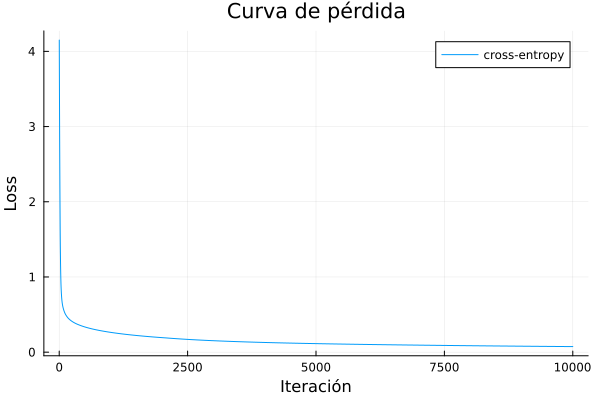

In [15]:
results(model, X_train, y_train, X_test, y_test, max_iter=10000)

# Perfil de desempeño

## Ejercicio 5
Implementar los siguientes métodos de descenso
* Gradiente con paso constante
* Gradiente con búsqueda de línea (condición de Armijo)
* Método de Newton
* Gradiente Conjugado No-Lineal (Fletcher-Reeves) y/o Método quasi-Newton BFGS

Cada método debe retornar: Estado (Convergió, máximas iteraciones alcanzadas, no convergió), número de iteraciones realizadas y valor final de $\|\nabla f\|$.

In [16]:
# Cada metodo debe retornar:
# 	Estado (convegio, maximas iteraciones alcanzadas, no convergio)
# 	Numero de iteraciones realizadas
# 	Valor final de ||grad(f)||
# TODO
function gradiente_const()
end


gradiente_const (generic function with 1 method)

In [17]:
# TODO
function gradiente_armijo()
end

gradiente_armijo (generic function with 1 method)

In [18]:
# TODO
function newton_raphson()
end

newton_raphson (generic function with 1 method)

In [19]:
# TODO
function gradiente_conj_no_lineal()
end

gradiente_conj_no_lineal (generic function with 1 method)

In [20]:
# TODO
function bfgs()
end

bfgs (generic function with 1 method)

## Ejercicio 6
Utilizar cada método con las funciones incluidas en el archivo `benchmark.jl`

## Ejercicio 7
Construir el Perfil de Desempeño de Dolan & Moré para la métrica de iteraciones. Graficar y realizar un breve análisis.

*Sugerencia:* El primer paso consiste en ejecutar cada uno de los algoritmos sobre cada problema y registrar el costo (iteraciones) de cada uno. Así, podemos formar la matriz $C$ de costos. Luego se puede calcular una matriz $R$ con la formula
$$r_{s,p} = \frac{c_{s,p}}{\min\{c_{j,p}: j \in S\}}$$

In [21]:
# TODO
function dolan_more()
	# construir perfil de desempeno de dolan & more para la metrica de iteraciones.
	# graficar y realizar un breve analisis.
	# sug: el primer paso consiste en ejecutar cada uno de los algoritmos sobre cada
	# problema y registrr el costo (iteraciones) de cada uno. Asi, podemos formar la
	# matriz C de costos. Luego se puede calcular una matriz R con la formula de r_sp
	# (ver clase de perfil de desempeno)
end

dolan_more (generic function with 1 method)